# MNIST Image Recognition -- MLP, CNN, and Transformer

This notebook trains and evaluates three neural network architectures on the MNIST handwritten digit dataset:
1. A shallow Multi-Layer Perceptron (MLP)
2. A Convolutional Neural Network (CNN)
3. A Transformer Encoder

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import math

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

BATCH_SIZE = 128
LEARNING_RATE = 1e-3
EPOCHS_MLP = 10
EPOCHS_CNN = 10
EPOCHS_TRANSFORMER = 15

torch.manual_seed(42)

Using device: mps


## Load MNIST Data

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 354kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.76MB/s]

Train samples: 60000
Test samples:  10000


## Model 1: Shallow Multi-Layer Perceptron (MLP)

In [3]:
class ShallowMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## Model 2: Convolutional Neural Network (CNN)

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Model 3: Transformer Encoder

In [5]:
class PatchEmbedding(nn.Module):
    """Split a 28x28 image into 4x4 patches and project to an embedding."""

    def __init__(self, patch_size=4, embed_dim=64):
        super().__init__()
        self.patch_size = patch_size
        num_patches = (28 // patch_size) ** 2  # 49 patches for 4x4
        self.proj = nn.Conv2d(1, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))

    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x)                        # (B, embed_dim, H/P, W/P)
        x = x.flatten(2).transpose(1, 2)        # (B, num_patches, embed_dim)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)          # (B, num_patches+1, embed_dim)
        x = x + self.pos_embed
        return x


class TransformerEncoder(nn.Module):
    def __init__(self, patch_size=4, embed_dim=64, num_heads=4, num_layers=2):
        super().__init__()
        self.patch_embed = PatchEmbedding(patch_size, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1,
            activation="gelu",
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Linear(embed_dim, 10)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.encoder(x)
        cls_out = x[:, 0]  # CLS token
        return self.head(cls_out)

## Training

In [6]:
def train_model(model, train_loader, epochs, lr=LEARNING_RATE):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        avg_loss = running_loss / total
        accuracy = 100.0 * correct / total
        print(f"  Epoch {epoch:2d}/{epochs} -- Loss: {avg_loss:.4f}  Acc: {accuracy:.2f}%")

    return model

In [7]:
print("=" * 50)
print("Training Shallow MLP")
print("=" * 50)
mlp_model = train_model(ShallowMLP(), train_loader, epochs=EPOCHS_MLP)

print()
print("=" * 50)
print("Training CNN")
print("=" * 50)
cnn_model = train_model(CNN(), train_loader, epochs=EPOCHS_CNN)

print()
print("=" * 50)
print("Training Transformer Encoder")
print("=" * 50)
transformer_model = train_model(TransformerEncoder(), train_loader, epochs=EPOCHS_TRANSFORMER)

Training Shallow MLP
  Epoch  1/10 -- Loss: 0.2666  Acc: 92.24%
  Epoch  2/10 -- Loss: 0.1096  Acc: 96.75%
  Epoch  3/10 -- Loss: 0.0737  Acc: 97.78%
  Epoch  4/10 -- Loss: 0.0533  Acc: 98.37%
  Epoch  5/10 -- Loss: 0.0407  Acc: 98.75%
  Epoch  6/10 -- Loss: 0.0316  Acc: 99.00%
  Epoch  7/10 -- Loss: 0.0248  Acc: 99.26%
  Epoch  8/10 -- Loss: 0.0195  Acc: 99.38%
  Epoch  9/10 -- Loss: 0.0163  Acc: 99.49%
  Epoch 10/10 -- Loss: 0.0155  Acc: 99.47%

Training CNN
  Epoch  1/10 -- Loss: 0.2169  Acc: 93.73%
  Epoch  2/10 -- Loss: 0.0553  Acc: 98.21%
  Epoch  3/10 -- Loss: 0.0391  Acc: 98.82%
  Epoch  4/10 -- Loss: 0.0278  Acc: 99.13%
  Epoch  5/10 -- Loss: 0.0228  Acc: 99.29%
  Epoch  6/10 -- Loss: 0.0181  Acc: 99.44%
  Epoch  7/10 -- Loss: 0.0146  Acc: 99.52%
  Epoch  8/10 -- Loss: 0.0120  Acc: 99.61%
  Epoch  9/10 -- Loss: 0.0099  Acc: 99.66%
  Epoch 10/10 -- Loss: 0.0087  Acc: 99.72%

Training Transformer Encoder
  Epoch  1/15 -- Loss: 0.6378  Acc: 79.32%
  Epoch  2/15 -- Loss: 0.2547  A

## Testing

In [8]:
def test_model(model, test_loader):
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    class_correct = [0] * 10
    class_total = [0] * 10

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            for label, pred in zip(labels, preds):
                class_total[label.item()] += 1
                if label == pred:
                    class_correct[label.item()] += 1

    overall_acc = 100.0 * correct / total
    per_class = {
        d: 100.0 * class_correct[d] / class_total[d] for d in range(10)
    }
    return overall_acc, per_class

In [9]:
models = {
    "Shallow MLP": mlp_model,
    "CNN": cnn_model,
    "Transformer Encoder": transformer_model,
}

results = {}
for name, model in models.items():
    acc, per_class = test_model(model, test_loader)
    results[name] = acc
    print(f"\n{name} -- Test Accuracy: {acc:.2f}%")
    for digit in range(10):
        print(f"  Digit {digit}: {per_class[digit]:.1f}%")

print("\n" + "=" * 50)
print("SUMMARY")
print("=" * 50)
for name, acc in results.items():
    print(f"  {name:25s} {acc:.2f}%")


Shallow MLP -- Test Accuracy: 97.80%
  Digit 0: 99.4%
  Digit 1: 99.2%
  Digit 2: 98.2%
  Digit 3: 97.7%
  Digit 4: 98.1%
  Digit 5: 97.6%
  Digit 6: 97.1%
  Digit 7: 99.0%
  Digit 8: 96.3%
  Digit 9: 95.1%

CNN -- Test Accuracy: 99.10%
  Digit 0: 99.4%
  Digit 1: 99.6%
  Digit 2: 99.4%
  Digit 3: 99.5%
  Digit 4: 99.2%
  Digit 5: 99.0%
  Digit 6: 98.5%
  Digit 7: 99.0%
  Digit 8: 98.8%
  Digit 9: 98.4%

Transformer Encoder -- Test Accuracy: 97.82%
  Digit 0: 99.1%
  Digit 1: 99.4%
  Digit 2: 98.7%
  Digit 3: 97.2%
  Digit 4: 98.4%
  Digit 5: 97.9%
  Digit 6: 99.3%
  Digit 7: 97.4%
  Digit 8: 95.4%
  Digit 9: 95.3%

SUMMARY
  Shallow MLP               97.80%
  CNN                       99.10%
  Transformer Encoder       97.82%


## Sample Predictions

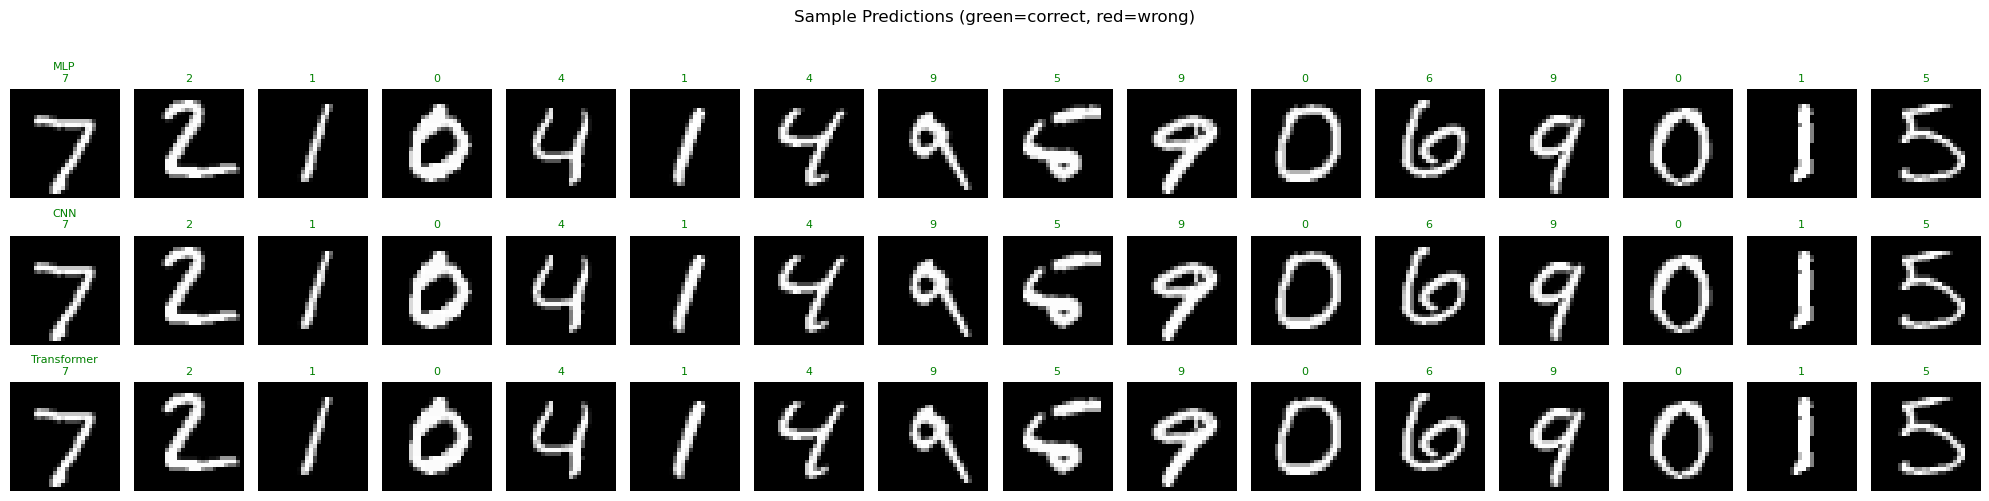

In [10]:
sample_images, sample_labels = next(iter(test_loader))
sample_images_dev = sample_images[:16].to(device)

fig, axes = plt.subplots(3, 16, figsize=(20, 5))
model_list = [("MLP", mlp_model), ("CNN", cnn_model), ("Transformer", transformer_model)]

for row, (name, model) in enumerate(model_list):
    model.eval()
    with torch.no_grad():
        preds = model(sample_images_dev).argmax(1).cpu()
    for col in range(16):
        ax = axes[row, col]
        ax.imshow(sample_images[col].squeeze(), cmap="gray")
        ax.axis("off")
        true_label = sample_labels[col].item()
        pred_label = preds[col].item()
        color = "green" if pred_label == true_label else "red"
        if col == 0:
            ax.set_title(f"{name}\n{pred_label}", fontsize=8, color=color)
        else:
            ax.set_title(str(pred_label), fontsize=8, color=color)

plt.suptitle("Sample Predictions (green=correct, red=wrong)", y=1.02)
plt.tight_layout()
plt.show()